In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from mphsweepkit.plot_data import DataPlot, PlotSettings
import matplotlib.pyplot as plt

In [3]:
# 1) Load result data exported by CascadedSweepModel.save_result_data(...)
result_dir = Path("result_data")  # adjust if needed
dp = DataPlot.from_result_folder(result_dir)

# 2) Inspect loaded data
print("Input shape:", dp.input_df.shape)
print("Output shape:", dp.output_df.shape)
print("Combined shape:", dp.combined_df.shape)

print("\nInput columns:", dp.input_columns())
print("Output columns:", dp.output_columns())

# 3) Access metadata
y_col = dp.output_columns()[0]
print(f"\nSelected output column: {y_col}")
print("Label:", dp.get_label(y_col))
print("Unit:", dp.get_unit(y_col))
print("Axis label:", dp.format_axis_label(y_col))

# 4) Access combined dataframe
display(dp.combined_df.head())

Input shape: (159, 8)
Output shape: (159, 3)
Combined shape: (159, 11)

Input columns: ['hor_slit', 'vert_slit', 'w', 'l_r', 'a_e', 'matsw.comp1.core', 'b_mean', 'freq']
Output columns: ['p_loss', 'p_mag', 'p_el']

Selected output column: p_loss
Label: $p_\mathrm{loss}$
Unit: W /m^3
Axis label: $p_\mathrm{loss}$ [W /m^3]


,hor_slit,vert_slit,w,l_r,a_e,matsw.comp1.core,b_mean,freq,p_loss,p_mag,p_el
name,,,,,,,,,,,
label,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$p_\mathrm{loss}$,$p_\mathrm{mag}$,$p_\mathrm{el}$
unit,um,um,mm,mm,mm,NaN,mT,kHz,W /m^3,W /m^3,W /m^3
group,Geometry Sweep,Geometry Sweep,Geometry Sweep,Geometry Sweep,Geometry Sweep,Material Sweep,Excitation Sweep,Frequency Sweep,NaN,NaN,NaN
0,0.0,0.0,5.0,0.0,5.0,2.0,25.0,100.0,1065.208504791815,1016.230502858757,48.978001933057314
1,0.0,0.0,5.0,0.0,5.0,2.0,25.0,200.0,2817.933227748244,2542.728370845599,275.20485690264763


Exemplary Visualization of average loss density in dependence of the geometry

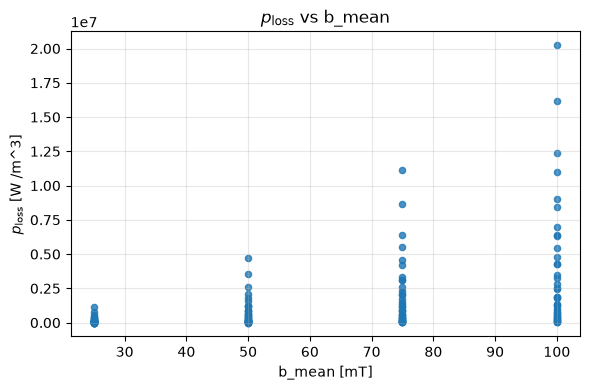

In [4]:
# Quick plotting showcase using DataPlot-loaded data

import pandas as pd
import numpy as np

# Keep selecting by semantic names
x_col = dp.input_columns()[6]   # e.g. 'b_mean'
y_col = dp.output_columns()[0]  # e.g. 'p_loss'

# Robust MultiIndex/flat-column resolver
def _resolve_col(df, col_name):
    if col_name in df.columns:
        return col_name
    if isinstance(df.columns, pd.MultiIndex):
        hits = [c for c in df.columns if c[0] == col_name]
        if len(hits) == 1:
            return hits[0]
        if len(hits) > 1:
            # prefer output-like columns (group None) if ambiguous
            for c in hits:
                if len(c) >= 3 and (len(c) < 4 or c[3] is None):
                    return c
            return hits[0]
    raise KeyError(f"Column '{col_name}' not found.")

x_key = _resolve_col(dp.combined_df, x_col)
y_key = _resolve_col(dp.combined_df, y_col)

# Force plain numeric 1D arrays
x_vals = pd.to_numeric(dp.combined_df.loc[:, x_key], errors="coerce").to_numpy(dtype=float)
y_vals = pd.to_numeric(dp.combined_df.loc[:, y_key], errors="coerce").to_numpy(dtype=float)

# Drop invalid rows
mask = np.isfinite(x_vals) & np.isfinite(y_vals)
x_vals = x_vals[mask]
y_vals = y_vals[mask]

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x_vals, y_vals, s=20, alpha=0.8)

ax.set_xlabel(str(dp.format_axis_label(x_key)))
ax.set_ylabel(str(dp.format_axis_label(y_key)))
ax.set_title(f"{str(dp.get_label(y_key))} vs {str(dp.get_label(x_key))}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

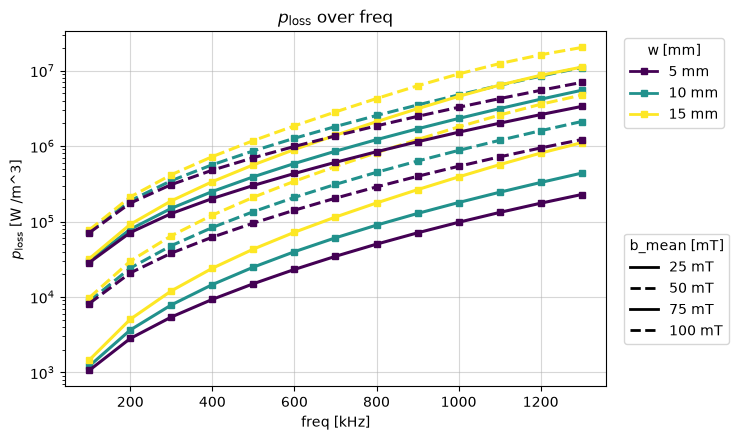

In [5]:
from mphsweepkit.plot_data import PlotSettings

fig, ax = plt.subplots(figsize=(7.5, 4.5))

custom_settings = PlotSettings(
    x_scale="linear",          # change x-axis scale
    y_scale="log",             # keep y-axis logarithmic
    show_grid=True,
    grid_which="major",
    grid_alpha=0.5,
    marker="s",
    marker_size=5,
    line_width=2.2,
    color_map_name="viridis",
    line_styles=("-", "--"),
    show_color_legend=True,
    show_style_legend=True,
    use_tight_layout=True
)

dp.y_over_x_with_color_and_style(
    ax=ax,
    y_col="p_loss",
    x_col="freq",
    color_col="w",
    style_col="b_mean",
    settings=custom_settings,
)

plt.show()